In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    WhiteKernel, ConstantKernel as C, DotProduct
)

from scipy.stats import multivariate_normal
from scipy.linalg import cholesky, solve_triangular

import GPy
import torch
import gpytorch

In [ ]:
def f(x):
    return np.sin(x) * np.exp(-x / 5) + 0.5 * np.sin(5 * x)

sigma_noise = 0.3


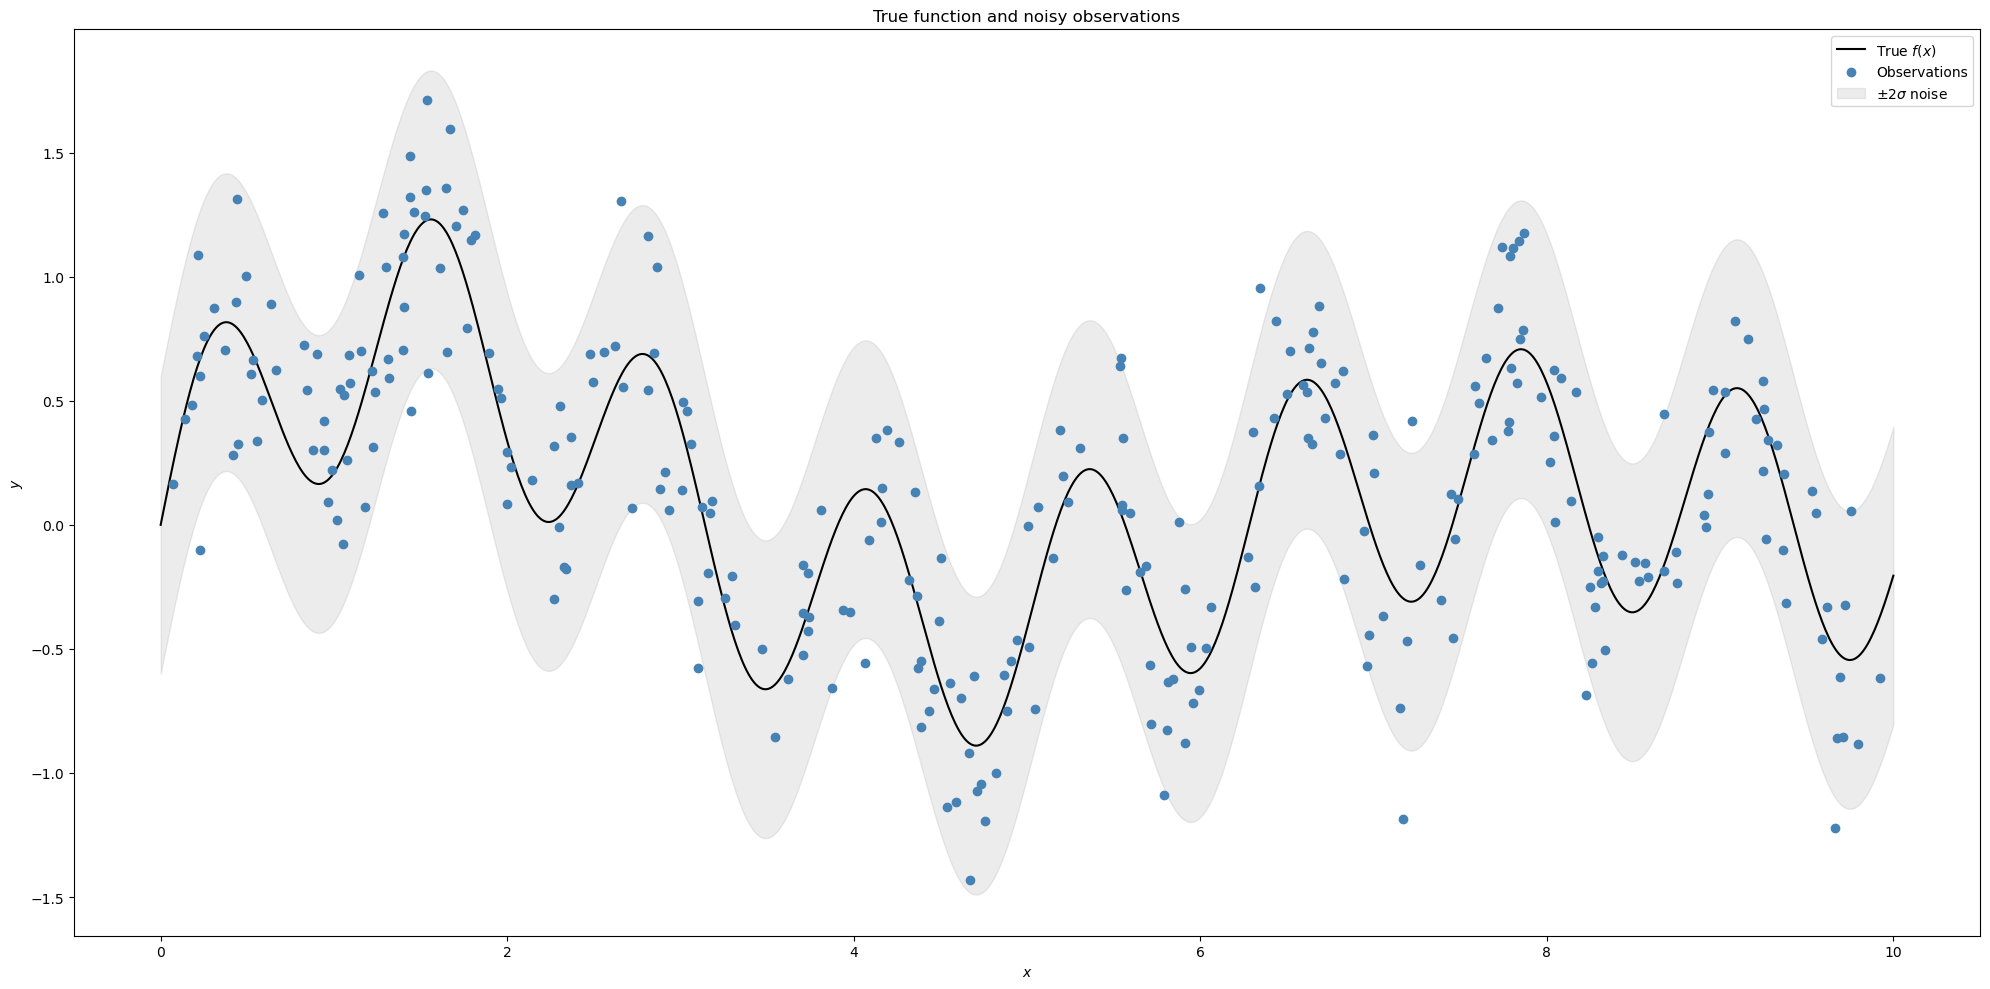

In [ ]:
rng = np.random.default_rng(42)

x_plot = np.linspace(0, 10, 1000)
y_plot = f(x_plot)

n_obs = 300
x_obs = np.sort(rng.uniform(0, 10, n_obs))
y_obs = f(x_obs) + rng.normal(0, sigma_noise, n_obs)

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_plot, y_plot, "k-", lw=1.5, label="True $f(x)$")
ax.scatter(x_obs, y_obs, color="steelblue", zorder=5, label="Observations")
ax.fill_between(x_plot, y_plot - 2*sigma_noise, y_plot + 2*sigma_noise,
                alpha=0.15, color="gray", label=r"$\pm 2\sigma$ noise")
ax.set(xlabel="$x$", ylabel="$y$", title="True function and noisy observations")
ax.legend()
plt.tight_layout()
plt.show()

Optimised:  ell1=0.303  sf1=0.493  ell2=0.368  sf2=0.615


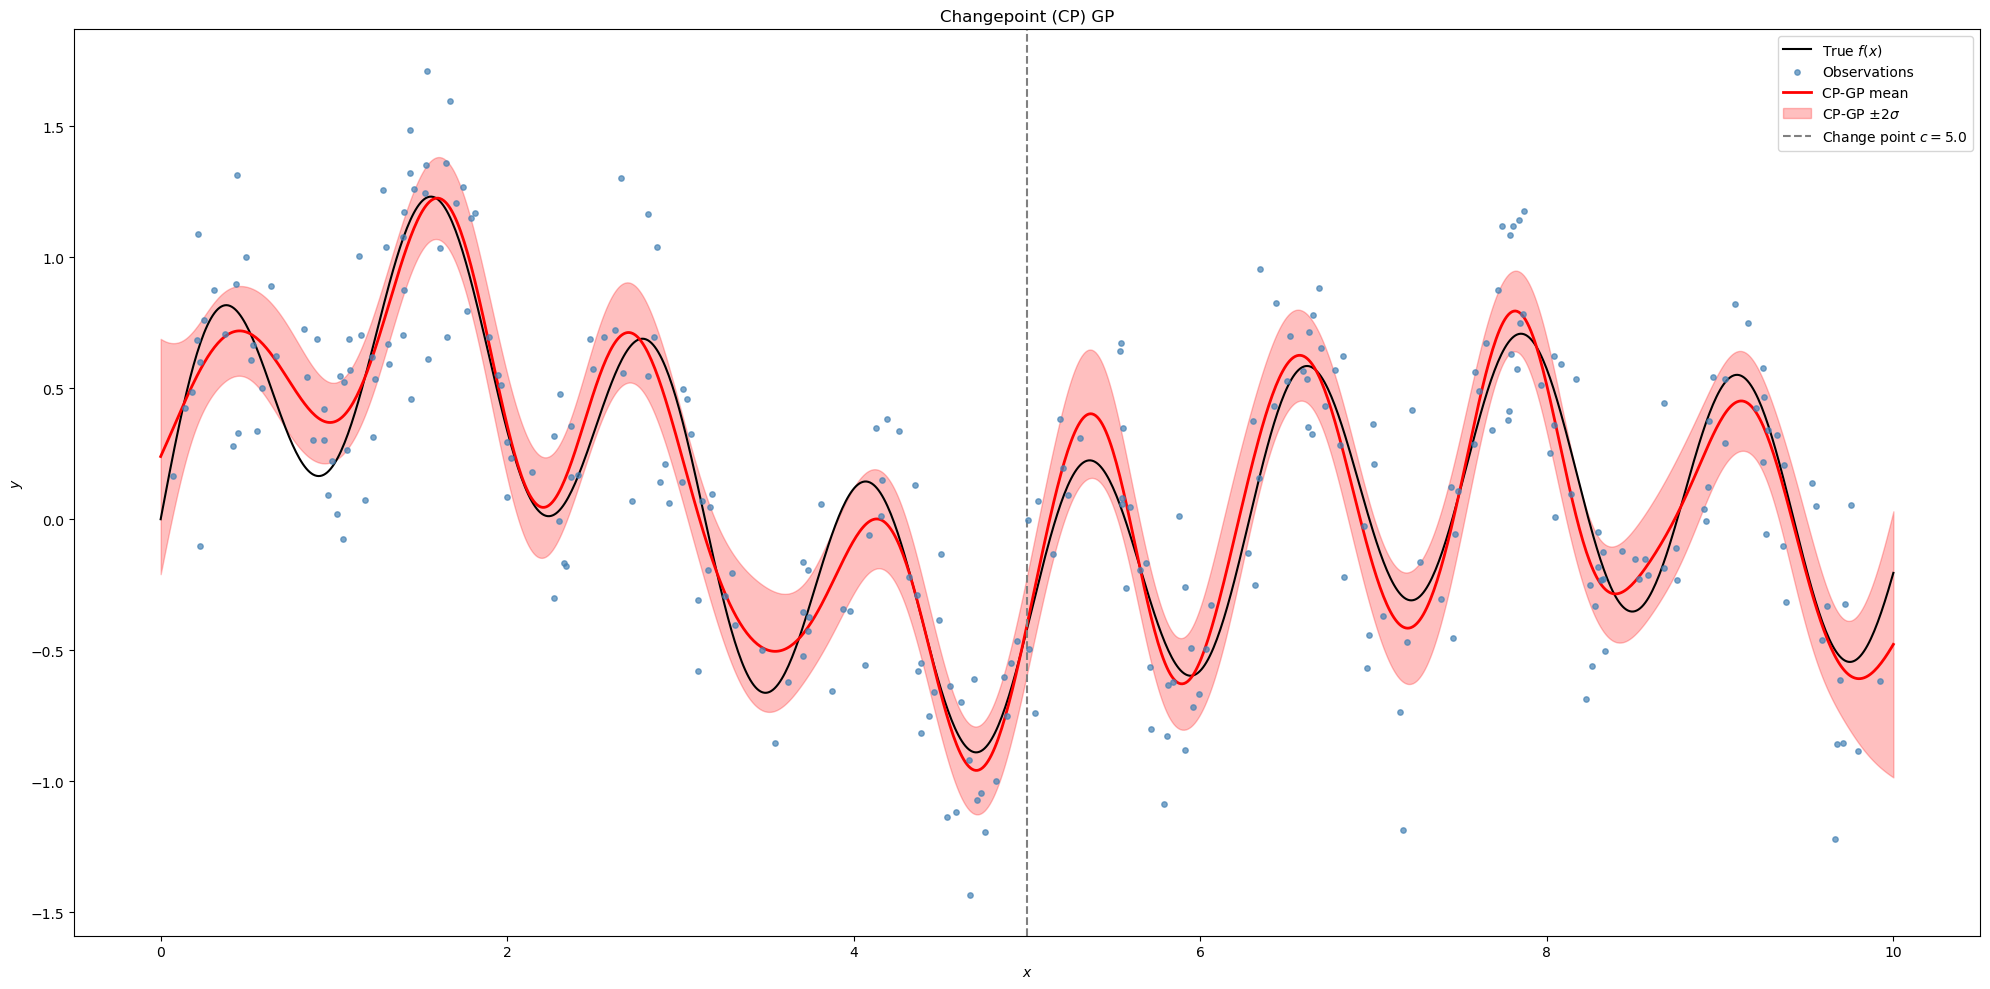

MAE: 0.0868
MSE: 0.0109


In [ ]:
from scipy.optimize import minimize

def sigmoid(x, c, s=5.0):
    return 1.0 / (1.0 + np.exp(-s * (x - c)))

def rbf(X1, X2, ell, sf):
    d2 = (X1[:, None] - X2[None, :]) ** 2
    return sf**2 * np.exp(-0.5 * d2 / ell**2)

def cp_kernel(X1, X2, ell1, sf1, ell2, sf2, c, s=5.0):
    sig1, sig2 = sigmoid(X1, c, s), sigmoid(X2, c, s)
    K1 = rbf(X1, X2, ell1, sf1)
    K2 = rbf(X1, X2, ell2, sf2)
    S  = sig1[:, None] * sig2[None, :]
    return S * K1 + (1.0 - S) * K2

def neg_log_marginal_likelihood(log_params, X, y, sn, c):
    ell1, sf1, ell2, sf2 = np.exp(log_params)
    n = len(X)
    K = cp_kernel(X, X, ell1, sf1, ell2, sf2, c) + sn**2 * np.eye(n)
    try:
        L = cholesky(K, lower=True)
    except Exception:
        return 1e10
    alpha = solve_triangular(L.T, solve_triangular(L, y, lower=True))
    lml = -0.5 * y @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * n * np.log(2 * np.pi)
    return -lml

c_cp = 5.0
p0   = np.log([2.0, 1.0, 0.3, 0.5])

res  = minimize(neg_log_marginal_likelihood, p0,
                args=(x_obs, y_obs, sigma_noise, c_cp),
                method='L-BFGS-B')

ell1, sf1, ell2, sf2 = np.exp(res.x)
print(f"Optimised:  ell1={ell1:.3f}  sf1={sf1:.3f}  ell2={ell2:.3f}  sf2={sf2:.3f}")

K_train = cp_kernel(x_obs, x_obs, ell1, sf1, ell2, sf2, c_cp) + sigma_noise**2 * np.eye(n_obs)
L_train = cholesky(K_train, lower=True)
alpha   = solve_triangular(L_train.T, solve_triangular(L_train, y_obs, lower=True))

K_star  = cp_kernel(x_plot, x_obs, ell1, sf1, ell2, sf2, c_cp)
K_ss    = cp_kernel(x_plot, x_plot, ell1, sf1, ell2, sf2, c_cp)

mu_cp   = K_star @ alpha
v       = solve_triangular(L_train, K_star.T, lower=True)
std_cp  = np.sqrt(np.clip(np.diag(K_ss) - np.sum(v**2, axis=0), 0, None))

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_plot, y_plot,  "k-",  lw=1.5, label="True $f(x)$")
ax.scatter(x_obs, y_obs, color="steelblue", s=15, zorder=5, alpha=0.7, label="Observations")
ax.plot(x_plot, mu_cp,   "r-",  lw=2, label="CP-GP mean")
ax.fill_between(x_plot, mu_cp - 2*std_cp, mu_cp + 2*std_cp,
                alpha=0.25, color="red", label=r"CP-GP $\pm 2\sigma$")
ax.axvline(c_cp, ls="--", color="gray", lw=1.5, label=f"Change point $c = {c_cp}$")
ax.set(xlabel="$x$", ylabel="$y$", title="Changepoint (CP) GP")
ax.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(mu_cp - y_plot))
mse = np.mean((mu_cp - y_plot) ** 2)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")


## Summary

This notebook builds a 1D Gaussian Process regression example with a **changepoint kernel**:

- Imports scientific Python and GP libraries (`numpy`, `matplotlib`, `scipy`, `sklearn`, `GPy`, `torch`, `gpytorch`).
- Defines a synthetic target function
  \(f(x)=\sin(x)e^{-x/5}+0.5\sin(5x)\), which mixes slow and fast behavior.
- Generates noisy observations from this function and visualizes the true signal, data points, and noise band.
- Implements a custom changepoint GP kernel that blends two RBF kernels using a sigmoid gate around a fixed changepoint \(c=5\).
- Fits kernel hyperparameters by minimizing negative log marginal likelihood (L-BFGS-B).
- Computes GP posterior mean and uncertainty on a dense test grid using Cholesky-based linear algebra.
- Plots predictions with confidence intervals and reports accuracy metrics (`MAE`, `MSE`) against the true function.

Overall, the notebook demonstrates why a nonstationary changepoint GP can model multi-scale, regime-changing signals better than a single stationary kernel.
